# Nội dung 2: ACRF-RNN Spark Pipeline

**Mục tiêu**: Xử lý dữ liệu tài chính của 491 công ty Trung Quốc (2010-2020)

## Các bước thực hiện
1. Import thư viện
2. Khởi tạo SparkSession
3. Load dữ liệu thô
4. Tiền xử lý dữ liệu
5. Phân tích khám phá dữ liệu
6. Chia tập Train/Val/Test
7. Chuẩn hóa đặc trưng
8. Lưu dữ liệu Parquet & Kiểm chứng
9. Xuất thống kê JSON & JSON Year-major
10. Kết thúc & Giải phóng bộ nhớ

## Import thư viện

In [ ]:
import os
import sys
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from datetime import datetime
from pathlib import Path
from pyspark.sql import SparkSession, functions as F
from pyspark.ml.feature import VectorAssembler, StandardScaler
from pyspark.ml.functions import vector_to_array
from pyspark.ml.util import DefaultParamsReader

## Khởi tạo SparkSession

In [ ]:
OUTPUT_DIR = Path('processed')
OUTPUT_DIR.mkdir(exist_ok=True)

spark = SparkSession.builder \
    .appName('ACRF-RNN-Preprocessing') \
    .master('local[2]') \
    .config('spark.driver.memory', '2048m') \
    .config('spark.sql.shuffle.partitions', '4') \
    .config('spark.hadoop.fs.defaultFS', 'file:///') \
    .getOrCreate()

spark.sparkContext.setLogLevel("WARN")
print("✓ SparkSession sẵn sàng")

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
26/06/01 15:00:27 WARN Utils: Your hostname, ngannt-VMware, resolves to a loopback address: 127.0.1.1; using 192.168.134.128 instead (on interface ens33)
26/06/01 15:00:27 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/06/01 15:00:28 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


✓ SparkSession sẵn sàng


## Load dữ liệu

In [ ]:
data_path = 'data/data.csv'

df_raw = spark.read.csv(data_path, header=True, inferSchema=True)

for field in df_raw.schema.fields:
    print(f"  {field.name:30s} : {str(field.dataType)}")

  STPT                           : IntegerType()
  IsSuspend                      : IntegerType()
  MarketValueOfDebt              : DoubleType()
  MarketValueOfEquity            : DoubleType()
  MarketValueOfCompany1          : DoubleType()
  MarketValueOfCompany2          : DoubleType()
  ExpectedReturnRate             : DoubleType()
  EquityValueVolatility          : DoubleType()
  DebtVolatility                 : DoubleType()
  AssetValueVolatility1          : DoubleType()
  AssetValueVolatility2          : DoubleType()
  TradingDays                    : DoubleType()
  DDBhsh                         : DoubleType()
  DDmerton                       : DoubleType()
  DDKMV                          : DoubleType()
  OScore                         : DoubleType()
  RiskCoefficient                : DoubleType()
  ROA                            : DoubleType()
  IndROA                         : DoubleType()
  DownsideRisk                   : DoubleType()
  TotalAssets                    : Dou

## Tiền xử lí dữ liệu

In [ ]:
num_rows = df_raw.count()
num_cols = len(df_raw.columns)
print(f"Kích thước dữ liệu: ({num_rows:,}; {num_cols})")

total_null = sum(list(df_raw.select([F.count(F.when(F.col(c).isNull(), c)) for c in df_raw.columns]).first()))
total_unknown = sum(list(df_raw.select([F.count(F.when(F.lower(F.col(c).cast("string")) == "unknown", c)) for c in df_raw.columns]).first()))

print(f"Tổng số lượng giá trị thiếu (Null): {total_null:,}")
print(f"Tổng số lượng chứa giá trị 'unknown': {total_unknown:,}")

target_col = "label"

Kích thước dữ liệu: (4,910; 211)


26/06/01 15:00:40 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


Tổng số lượng giá trị thiếu (Null): 0
Tổng số lượng chứa giá trị 'unknown': 0


## Phân tích khám phá dữ liệu

In [ ]:
num_rows = df_raw.count()

print("Phân bố nhãn:")
fraud_count = df_raw.filter(F.col("label") == 1).count()
benign_count = df_raw.filter(F.col("label") == 0).count()

fraud_pct = (fraud_count / num_rows) * 100
benign_pct = (benign_count / num_rows) * 100
print(f"  FRAUD (=1)          :  {fraud_count:,} ({fraud_pct:.2f}%)")
print(f"  BENIGN (=0)         :  {benign_count:,} ({benign_pct:.2f}%)")

print("\nThống kê phân phối nhãn (Fraud/Benign) theo từng năm")
# Tính toán bảng chéo (Crosstab) giữa Year và Label trực tiếp trên Spark
pivot_df = df_raw.groupBy("year").pivot("label", [0, 1]).count().fillna(0)
summary_year = (
    pivot_df.withColumnRenamed("0", "Benign(0)")
    .withColumnRenamed("1", "Fraud(1)")
    .withColumn("Total", F.col("Benign(0)") + F.col("Fraud(1)"))
    .withColumn("Fraud%", F.round((F.col("Fraud(1)") / F.col("Total")) * 100, 2))
    .sort("year")
)
summary_year.show()

important_features = ["TotalAssets", "OperatingRevenue", "ROA", "D000101000", "D000109000"]

print("Thống kê mô tả các thuộc tính tiêu biểu")
df_raw.select(important_features).describe().show()

Phân bố nhãn:
  FRAUD (=1)          :  1,183 (24.09%)
  BENIGN (=0)         :  3,727 (75.91%)

Thống kê phân phối nhãn (Fraud/Benign) theo từng năm
+----+---------+--------+-----+------+
|year|Benign(0)|Fraud(1)|Total|Fraud%|
+----+---------+--------+-----+------+
|2010|      386|     105|  491| 21.38|
|2011|      361|     130|  491| 26.48|
|2012|      358|     133|  491| 27.09|
|2013|      375|     116|  491| 23.63|
|2014|      377|     114|  491| 23.22|
|2015|      351|     140|  491| 28.51|
|2017|      369|     122|  491| 24.85|
|2018|      364|     127|  491| 25.87|
|2019|      381|     110|  491|  22.4|
|2020|      405|      86|  491| 17.52|
+----+---------+--------+-----+------+

Thống kê mô tả các thuộc tính tiêu biểu
+-------+--------------------+--------------------+-------------------+--------------------+--------------------+
|summary|         TotalAssets|    OperatingRevenue|                ROA|          D000101000|          D000109000|
+-------+--------------------+-------

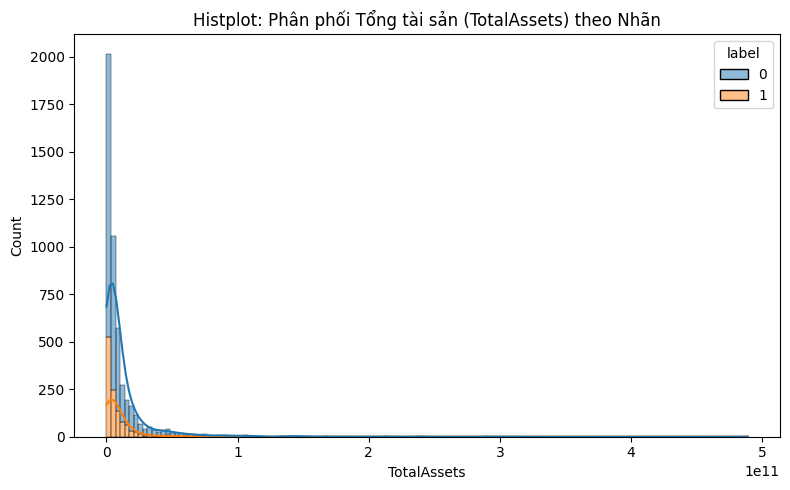

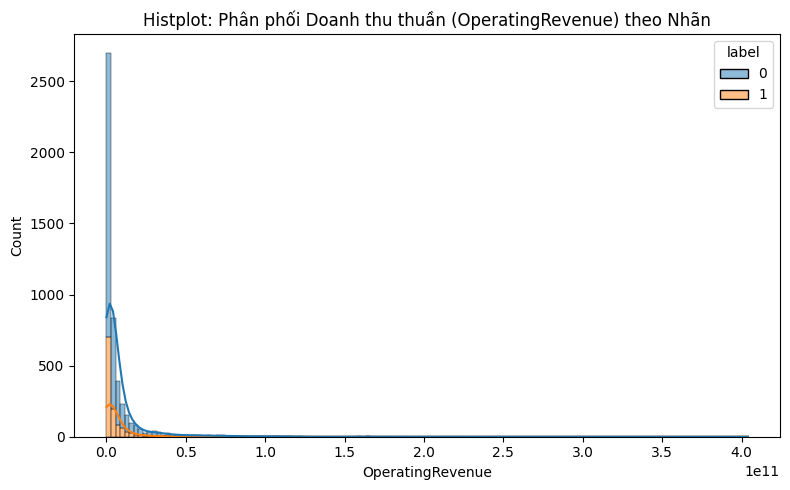

In [ ]:
pdf_plot = df_raw.select(["label", "year", "TotalAssets", "OperatingRevenue"]).toPandas()

# Phân phối Tổng tài sản (Quy mô doanh nghiệp)
plt.figure(figsize=(8, 5))
sns.histplot(data=pdf_plot, x="TotalAssets", hue="label", kde=True, multiple="stack")
plt.title("Histplot: Phân phối Tổng tài sản (TotalAssets) theo Nhãn")
plt.tight_layout()
plt.show()

# Phân phối Doanh thu thuần (Khả năng tạo dòng tiền thô)
plt.figure(figsize=(8, 5))
sns.histplot(data=pdf_plot, x="OperatingRevenue", hue="label", kde=True, multiple="stack")
plt.title("Histplot: Phân phối Doanh thu thuần (OperatingRevenue) theo Nhãn")
plt.tight_layout()
plt.show()

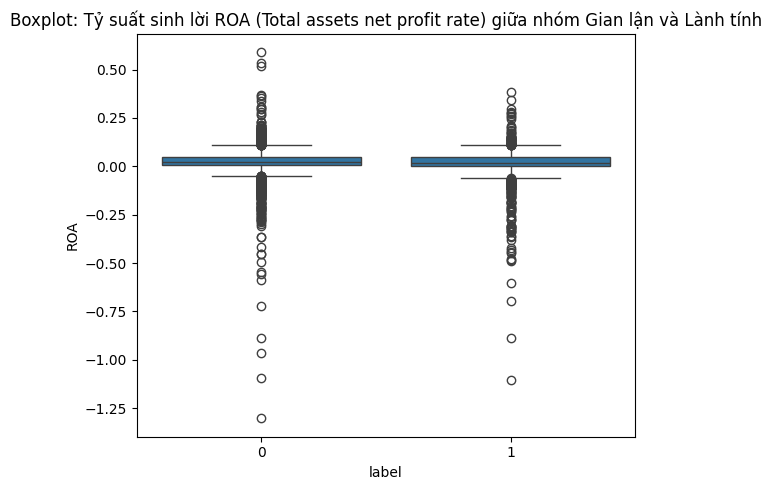

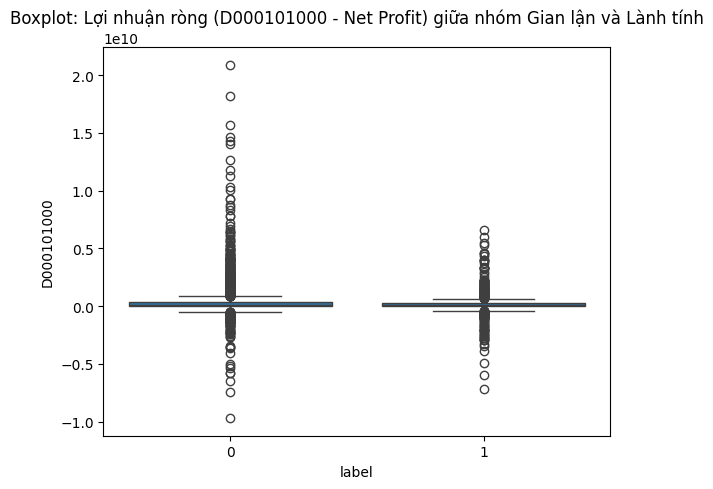

In [ ]:
pdf_boxplot = df_raw.select(["label", "ROA", "D000101000"]).toPandas()

# Biến động tỷ suất sinh lời ROA (Gian lận thường có ROA biến động cực đoan)
plt.figure(figsize=(6, 5))
sns.boxplot(data=pdf_boxplot, x="label", y="ROA")
plt.title("Boxplot: Tỷ suất sinh lời ROA (Total assets net profit rate) giữa nhóm Gian lận và Lành tính")
plt.tight_layout()
plt.show()

# Biến động Lợi nhuận ròng D000101000 (Phát hiện nhiễu và bất thường sổ sách)
plt.figure(figsize=(6, 5))
sns.boxplot(data=pdf_boxplot, x="label", y="D000101000")
plt.title("Boxplot: Lợi nhuận ròng (D000101000 - Net Profit) giữa nhóm Gian lận và Lành tính")
plt.tight_layout()
plt.show()

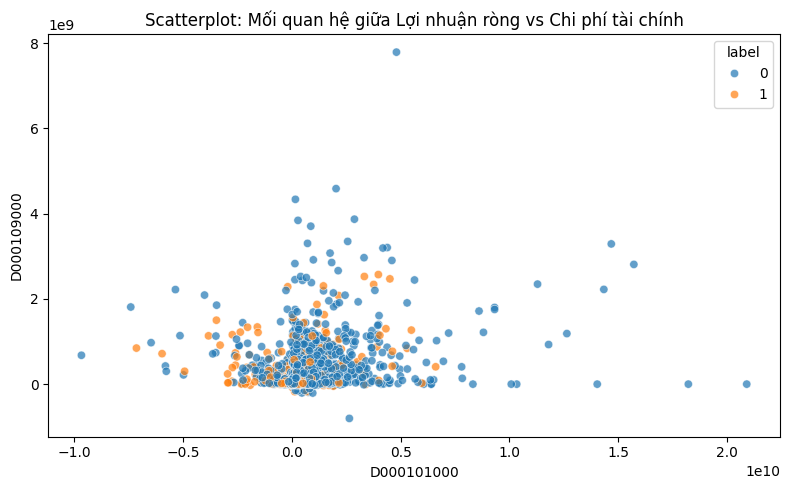

In [ ]:
pdf_scatter = df_raw.select(["label", "D000101000", "D000109000"]).toPandas()

# Tương quan giữa Lợi nhuận ròng và Chi phí nợ vay/tài chính
plt.figure(figsize=(8, 5))
sns.scatterplot(data=pdf_scatter, x="D000101000", y="D000109000", hue="label", alpha=0.7)
plt.title("Scatterplot: Mối quan hệ giữa Lợi nhuận ròng vs Chi phí tài chính")
plt.tight_layout()
plt.show()

## Chia tập Train/Val/Test

In [ ]:
YEAR_COL = "year"

# Phân tách DataFrame thô (df_raw) thành các tập dữ liệu độc lập
train_raw = df_raw.filter(F.col(YEAR_COL) <= 2016)
val_raw = df_raw.filter(F.col(YEAR_COL) == 2017)
test_2018_raw = df_raw.filter(F.col(YEAR_COL) == 2018)
test_2019_raw = df_raw.filter(F.col(YEAR_COL) == 2019)
test_2020_raw = df_raw.filter(F.col(YEAR_COL) == 2020)


# Hàm tính toán nhanh các chỉ số đếm nhãn cho từng tập
def get_split_stats(df, name):
    total = df.count()
    if total == 0:
        return {"Tập": name, "Records": "0", "Fraud(1)": "0", "Benign(0)": "0", "Fraud%": "0.00%"}

    fraud = df.filter(F.col("label") == 1).count()
    benign = total - fraud
    fraud_pct = (fraud / total) * 100

    return {
        "Tập": name,
        "Records": f"{total:,}",
        "Fraud(1)": f"{fraud:,}",
        "Benign(0)": f"{benign:,}",
        "Fraud%": f"{fraud_pct:.2f}%"
    }

# Thu thập dữ liệu thống kê từ các tập đã chia
stats_list = [
    get_split_stats(train_raw, "Train (<=2016)"),
    get_split_stats(val_raw, "Val (2017)"),
    get_split_stats(test_2018_raw, "Test 2018"),
    get_split_stats(test_2019_raw, "Test 2019"),
    get_split_stats(test_2020_raw, "Test 2020")
]

print(f"{'Tập':<16} {'Records':<12} {'Fraud(1)':<12} {'Benign(0)':<12} {'Fraud%':<10}")
print("-" * 65)
for s in stats_list:
    print(f"{s['Tập']:<16} {s['Records']:<12} {s['Fraud(1)']:<12} {s['Benign(0)']:<12} {s['Fraud%']:<10}")
print("\n✓ Chia tập hoàn tất")

Tập              Records      Fraud(1)     Benign(0)    Fraud%    
-----------------------------------------------------------------
Train (<=2016)   2,946        738          2,208        25.05%    
Val (2017)       491          122          369          24.85%    
Test 2018        491          127          364          25.87%    
Test 2019        491          110          381          22.40%    
Test 2020        491          86           405          17.52%    

✓ Chia tập hoàn tất


## Chuẩn hóa đặc trưng

In [ ]:
# Tách danh sách cột đặc trưng
metadata_cols = ["Symbol", "year", "label"]
feature_cols = [c for c in df_raw.columns if c not in metadata_cols]

print(f"  ✓ Tổng số lượng đặc trưng đầu vào tiến hành gộp: {len(feature_cols)}")

# Khởi tạo VectorAssembler để gộp phẳng các thuộc tính thành cột 'features_vec'
assembler = VectorAssembler(inputCols=feature_cols, outputCol="features_vec")

print("\n[1/4] Đang tiến hành ép cấu trúc Vector phẳng...")
train_assembled = assembler.transform(train_raw)
val_assembled = assembler.transform(val_raw)
test_2018_assembled = assembler.transform(test_2018_raw)
test_2019_assembled = assembler.transform(test_2019_raw)
test_2020_assembled = assembler.transform(test_2020_raw)
print(f"  ✓ {len(feature_cols)} features đã được assembled thành công.")

# Khởi tạo cấu hình StandardScaler (Mean = 0, Std = 1)
scaler = StandardScaler(
    inputCol="features_vec",
    outputCol="scaled_features",
    withMean=True,
    withStd=True
)

# FIT tham số toán học trên tập Train (<=2016) để chống Data Leakage
print("\n[2/4] Fit StandardScaler trên training data (2010-2016)...")
train_assembled.cache()
scaler_model = scaler.fit(train_assembled)
print("  ✓ Bộ Scaler model đã fitted.")

# Lưu scaler_model để tái sử dụng
print(f"\n[3/4] Đang ghi file scaler_model ra thư mục lưu trữ...")
scaler_model_path = str(OUTPUT_DIR / "scaler_model")
scaler_model.write().overwrite().save(scaler_model_path)
print(f"  ✓ Scaler model đã được lưu thành công tại: {scaler_model_path}")

# TRANSFORM độc lập thông số đã học lên từng tập dữ liệu thô
print("\n[4/4] Transform độc lập từng tập dữ liệu...")

train_scaled = scaler_model.transform(train_assembled)
val_scaled = scaler_model.transform(val_assembled)
test_2018_scaled = scaler_model.transform(test_2018_assembled)
test_2019_scaled = scaler_model.transform(test_2019_assembled)
test_2020_scaled = scaler_model.transform(test_2020_assembled)

# Giải phóng bộ nhớ đệm
train_assembled.unpersist()

print("\n  ✓ Hoàn thành chuẩn hóa đặc trưng!")

  ✓ Tổng số lượng đặc trưng đầu vào tiến hành gộp: 208

[1/4] Đang tiến hành ép cấu trúc Vector phẳng...
  ✓ 208 features đã được assembled thành công.

[2/4] Fit StandardScaler trên training data (2010-2016)...


  ✓ Bộ Scaler model đã fitted.

[3/4] Đang ghi file scaler_model ra thư mục lưu trữ...


  ✓ Scaler model đã được lưu thành công tại: processed/scaler_model

[4/4] Transform độc lập từng tập dữ liệu...

  ✓ Hoàn thành chuẩn hóa đặc trưng!


In [ ]:
# Tính toán thống kê trước khi chuẩn hóa
# Lấy các mảng giá trị Mean (Trung bình) và Std (Độ lệch chuẩn) mà mô hình đã học được từ tập Train
train_mean_array = scaler_model.mean.toArray()
train_std_array = scaler_model.std.toArray()

# TotalAssets (Tài sản), ROA (Sinh lời), Growth (Tăng trưởng)
sample_features = ["TotalAssets", "OperatingRevenue", "ROA"]
sample_indices = [feature_cols.index(c) for c in sample_features]

print("✓ Đã khởi tạo công cụ trích xuất tham số toán học thành công.")

✓ Đã khởi tạo công cụ trích xuất tham số toán học thành công.


## Lưu dữ liệu Parquet & Kiểm chứng

In [ ]:
datasets = {
    "train.parquet": train_scaled,
    "val.parquet": val_scaled,
    "test_2018.parquet": test_2018_scaled,
    "test_2019.parquet": test_2019_scaled,
    "test_2020.parquet": test_2020_scaled
}

# Các cột cần lưu: Symbol, year, 208 features (đã scale phẳng), label
save_cols = ["Symbol", "year"] + feature_cols + ["label"]

print("\n[Lưu dữ liệu Parquet]")
for filename, df in datasets.items():
    output_path = OUTPUT_DIR / filename

    # Giải nén Vector thành các cột phẳng độc lập TRƯỚC KHI LƯU bằng Spark
    df_arr = df.withColumn("feat_array", vector_to_array(F.col("scaled_features")))
    df_flat = df_arr
    for i, col_name in enumerate(feature_cols):
        df_flat = df_flat.withColumn(col_name, F.col("feat_array")[i])

    # Ghi file Parquet vật lý đè thẳng ra thư mục processed1
    df_flat.select(save_cols).write.mode("overwrite").parquet(str(output_path))

    # Thống kê hiển thị
    num_rows = df_flat.count()
    num_cols = len(save_cols)
    print(f"  ✓ Đã lưu: {filename:<18} | {num_rows:>6,} dòng | {num_cols:>3} cột")

print("\nKiểm tra Schema tập Train:")
check_df = spark.read.parquet(str(OUTPUT_DIR / "train.parquet"))
check_df.printSchema()


[Lưu dữ liệu Parquet]


  ✓ Đã lưu: train.parquet      |  2,946 dòng | 211 cột
  ✓ Đã lưu: val.parquet        |    491 dòng | 211 cột
  ✓ Đã lưu: test_2018.parquet  |    491 dòng | 211 cột
  ✓ Đã lưu: test_2019.parquet  |    491 dòng | 211 cột
  ✓ Đã lưu: test_2020.parquet  |    491 dòng | 211 cột

Kiểm tra Schema tập Train:
root
 |-- Symbol: integer (nullable = true)
 |-- year: integer (nullable = true)
 |-- STPT: double (nullable = true)
 |-- IsSuspend: double (nullable = true)
 |-- MarketValueOfDebt: double (nullable = true)
 |-- MarketValueOfEquity: double (nullable = true)
 |-- MarketValueOfCompany1: double (nullable = true)
 |-- MarketValueOfCompany2: double (nullable = true)
 |-- ExpectedReturnRate: double (nullable = true)
 |-- EquityValueVolatility: double (nullable = true)
 |-- DebtVolatility: double (nullable = true)
 |-- AssetValueVolatility1: double (nullable = true)
 |-- AssetValueVolatility2: double (nullable = true)
 |-- TradingDays: double (nullable = true)
 |-- DDBhsh: double (nullable = tru

## Xuất thống kê JSON & JSON Year-major

In [ ]:
stats_json_path = OUTPUT_DIR / "statistics.json"
processed_flat_json_path = OUTPUT_DIR / "processed_flat.json"

# Tính toán tự động phân bố theo năm
year_dist = {str(row['year']): row['count'] for row in df_raw.groupBy("year").count().collect()}

# Tính toán tự động kích thước các tập
split_sizes = {
    "train": train_raw.count(),
    "val": val_raw.count(),
    "test_2018": test_2018_raw.count(),
    "test_2019": test_2019_raw.count(),
    "test_2020": test_2020_raw.count()
}

# Tính toán và xuất file statistics.json
stats_total = {
    "total_records": train_raw.count() + val_raw.count() + test_2018_raw.count() + test_2019_raw.count() + test_2020_raw.count(),
    "fraud_records": df_raw.filter(F.col("label") == 1).count(),
    "benign_records": df_raw.filter(F.col("label") == 0).count(),
    "features_count": len(feature_cols),
    "split_sizes": split_sizes,
    "year_distribution": year_dist
}

with open(stats_json_path, "w") as f:
    json.dump(stats_total, f, indent=4)
print(f"  ✓ Đã xuất thành công: {OUTPUT_DIR.name}/{stats_json_path.name}")

# Đọc lại dữ liệu chuẩn hóa từ Parquet
all_parquet = []
for split_name in ['train', 'val', 'test_2018', 'test_2019', 'test_2020']:
    pq_path = OUTPUT_DIR / f"{split_name}.parquet"
    if pq_path.exists():
        df_part = pd.read_parquet(str(pq_path))
        all_parquet.append(df_part)

# Gộp tất cả và sắp xếp theo năm → công ty
df_all = pd.concat(all_parquet).sort_values(["year", "Symbol"])
years_sorted = sorted(df_all["year"].unique().tolist())

# Cấu trúc output (208 features đã chuẩn hóa phẳng + 1 nhãn label)
columns_out = feature_cols + ["label"]

# Build payload JSON dữ liệu chuỗi thời gian
json_data = []
for yr in years_sorted:
    yr_df = df_all[df_all["year"] == yr].sort_values("Symbol")
    symbols = yr_df["Symbol"].tolist()
    rows = yr_df[columns_out].values.tolist()
    json_data.append({'year': int(yr), 'symbols': symbols, 'rows': rows})

# Tính số lượng công ty
dynamic_num_companies = len(json_data[0]['symbols']) if json_data else 0

json_payload = {
    'format': 'main_py_compatible_year_major',
    'num_years': len(years_sorted),
    'num_companies_per_year': dynamic_num_companies,
    'num_columns_per_row': len(columns_out),
    'columns': columns_out,
    'data': json_data
}

with open(processed_flat_json_path, 'w', encoding='utf-8') as f:
    json.dump(json_payload, f, ensure_ascii=False)

print(f"  ✓ JSON year-major: {OUTPUT_DIR.name}/{processed_flat_json_path.name} "
      f"({processed_flat_json_path.stat().st_size / 1024 / 1024:.1f} MB)")

  ✓ Đã xuất thành công: processed/statistics.json
  ✓ JSON year-major: processed/processed_flat.json (20.5 MB)


In [ ]:
print("=" * 85)
print("Bảng thống kê đối chiếu đặc trưng tài chính trước và sau khi chuẩn hóa")
print("=" * 85)
print(f" {'Tên Đặc Trưng':<16} | {'Chỉ số':<8} | {'Trước chuẩn hóa (Raw Train)':<26} | {'Sau chuẩn hóa (Spark Scaled)':<26}")
print("-" * 85)

for name, idx in zip(sample_features, sample_indices):
    raw_stats = train_raw.select(
        F.mean(name).alias("mean"),
        F.stddev(name).alias("std"),
        F.min(name).alias("min"),
        F.max(name).alias("max")
    ).collect()[0]

    scaled_mean = 0.0
    scaled_std = 1.0

    # Tính an toàn biên độ Min, Max sau scale
    scaled_min = (raw_stats["min"] - train_mean_array[idx]) / (1.0 if train_std_array[idx] == 0 else train_std_array[idx])
    scaled_max = (raw_stats["max"] - train_mean_array[idx]) / (1.0 if train_std_array[idx] == 0 else train_std_array[idx])

    print(f" {name:<16} | {'Mean':<8} | {raw_stats['mean']:>26.4f} | {scaled_mean:>26.4f}")
    print(f" {'':<16} | {'StdDev':<8} | {raw_stats['std']:>26.4f} | {scaled_std:>26.4f}")
    print(f" {'':<16} | {'[Min]':<8} | {raw_stats['min']:>26.4f} | {scaled_min:>26.4f}")
    print(f" {'':<16} | {'[Max]':<8} | {raw_stats['max']:>26.4f} | {scaled_max:>26.4f}")
    print("-" * 85)

print("Nhận xét: Dữ liệu tài chính thô chênh lệch quy mô cực lớn (hàng tỷ so với số thập phân)")
print("Sau khi qua Spark StandardScaler, các cột đặc trưng đã được chuẩn hóa theo cơ chế z-score với mean xấp xỉ 0 và std xấp xỉ 1 trên tập dữ liệu train.")


Bảng thống kê đối chiếu đặc trưng tài chính trước và sau khi chuẩn hóa
 Tên Đặc Trưng    | Chỉ số   | Trước chuẩn hóa (Raw Train) | Sau chuẩn hóa (Spark Scaled)
-------------------------------------------------------------------------------------
 TotalAssets      | Mean     |            8219165793.9501 |                     0.0000
                  | StdDev   |           14935055334.1278 |                     1.0000
                  | [Min]    |              46891249.6300 |                    -0.5472
                  | [Max]    |          179000000000.0000 |                    11.4349
-------------------------------------------------------------------------------------
 OperatingRevenue | Mean     |            6018441550.0451 |                     0.0000
                  | StdDev   |           14271231119.5010 |                     1.0000
                  | [Min]    |                     0.0000 |                    -0.4217
                  | [Max]    |          199000000000.0000 

## Kết thúc & Giải phóng bộ nhớ

In [ ]:
# Đóng SparkSession để giải phóng RAM/Cache và giải phóng cổng kết nối JVM
if 'spark' in locals() or 'spark' in globals():
    spark.stop()
    print("✓ SparkSession stopped - Memory released")
else:
    print("! Không tìm thấy phiên làm việc Spark đang hoạt động.")

print("\nFiles đã lưu:")
print(f"  ✓ Statistics      : {OUTPUT_DIR.name}/statistics.json")
print(f"  ✓ Flat Parquet    : {OUTPUT_DIR.name}/[train|val|test_*].parquet")
print(f"  ✓ JSON year-major : {OUTPUT_DIR.name}/processed_flat.json")
print(f"  ✓ Scaler model    : {OUTPUT_DIR.name}/scaler_model")

✓ SparkSession stopped - Memory released

Files đã lưu:
  ✓ Statistics      : processed/statistics.json
  ✓ Flat Parquet    : processed/[train|val|test_*].parquet
  ✓ JSON year-major : processed/processed_flat.json
  ✓ Scaler model    : processed/scaler_model
